# Import libraries

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

# Read in cleaned data

In [2]:
df = pd.read_csv("data/nfl_sentiment_2025_cleaned.csv")
df.head()

,player_id,player_name,player_first_name,player_last_name,player_position,team_abbreviation,game_id,bta_game_id,game_week,game_start_time,...,stats_receiving_rec_yards,stats_receiving_rec_td,stats_tackles_tackle_total,stats_tackles_sacks,stats_interceptions_interceptions,stats_interceptions_passes_defended,stats_fumbles_fum_forced,total_touches,total_opportunities,fantasy_points_ppr
0,6644,Charley Hughlett,Charley,Hughlett,LS,PHI,148741,2025.09.04.PHI.DAL,1,2025-09-05 00:20:00+00:00,...,0,0,0,0.0,0,0,0,0,0,0.0
1,7229,Dante Fowler,Dante,Fowler,DE,DAL,148741,2025.09.04.PHI.DAL,1,2025-09-05 00:20:00+00:00,...,0,0,0,0.0,0,0,0,0,0,0.0
2,7268,Bryan Anger,Bryan,Anger,P,DAL,148741,2025.09.04.PHI.DAL,1,2025-09-05 00:20:00+00:00,...,0,0,0,0.0,0,0,0,0,0,0.0
3,8047,Lane Johnson,Lane,Johnson,T,PHI,148741,2025.09.04.PHI.DAL,1,2025-09-05 00:20:00+00:00,...,0,0,0,0.0,0,0,0,0,0,0.0
4,8112,C.J. Goodwin,C.J.,Goodwin,CB,DAL,148741,2025.09.04.PHI.DAL,1,2025-09-05 00:20:00+00:00,...,0,0,0,0.0,0,0,0,0,0,0.0


# 1D EDA
## Passing statistics

In [3]:
print(df.columns)

Index(['player_id', 'player_name', 'player_first_name', 'player_last_name',
       'player_position', 'team_abbreviation', 'game_id', 'bta_game_id',
       'game_week', 'game_start_time', 'opp_offense_dvoa', 'opp_defense_dvoa',
       'stats_snap_counts_offense_snaps', 'stats_passing_pass_attempts',
       'stats_passing_pass_completions', 'stats_passing_pass_yards',
       'stats_passing_pass_td', 'stats_passing_pass_int',
       'stats_passing_qb_rating', 'stats_rushing_rush_attempts',
       'stats_rushing_rush_yards', 'stats_rushing_rush_td',
       'stats_receiving_targets', 'stats_receiving_receptions',
       'stats_receiving_rec_yards', 'stats_receiving_rec_td',
       'stats_tackles_tackle_total', 'stats_tackles_sacks',
       'stats_interceptions_interceptions',
       'stats_interceptions_passes_defended', 'stats_fumbles_fum_forced',
       'total_touches', 'total_opportunities', 'fantasy_points_ppr'],
      dtype='object')


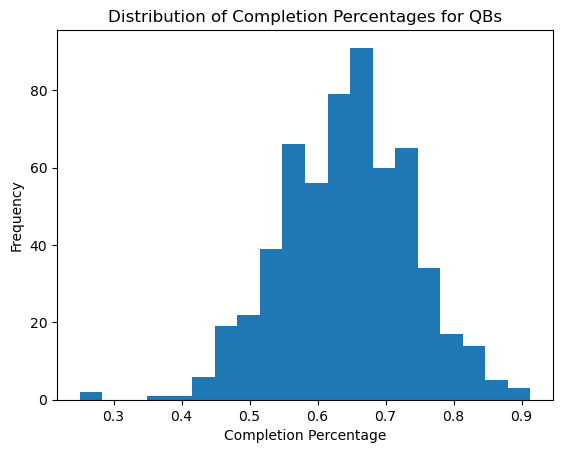

In [ ]:
# Completion percentage distribution for QBs only
qb_df = df[df['player_position'] == 'QB']
qb_df = qb_df[qb_df['stats_passing_pass_attempts'] > 10]  # Filter out QBs with few pass attempts
comp_pcts = qb_df['stats_passing_pass_completions'] / qb_df['stats_passing_pass_attempts']
plt.hist(comp_pcts, bins=20)
plt.title('Distribution of Completion Percentages for QBs')
plt.xlabel('Completion Percentage')
plt.ylabel('Frequency')
plt.show()

# Looks approximately normal

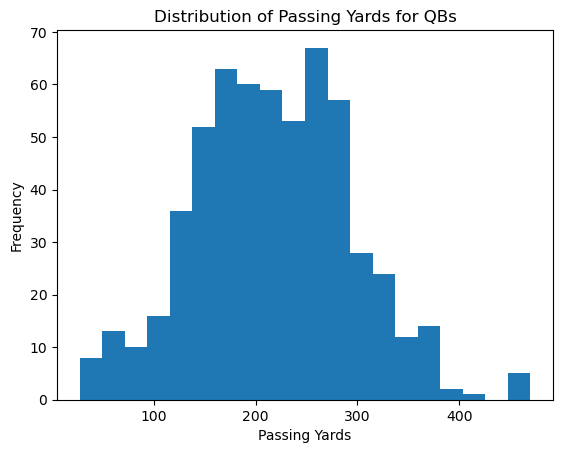

In [ ]:
# Passing yards distribution for QBs only
plt.hist(qb_df['stats_passing_pass_yards'], bins=20)
plt.title('Distribution of Passing Yards for QBs')
plt.xlabel('Passing Yards')
plt.ylabel('Frequency')
plt.show()

# Also looks normal-like

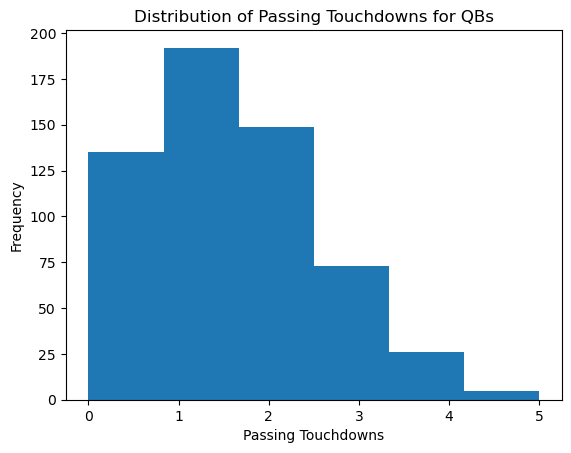

In [ ]:
# Touchdowns distribution for QBs only
plt.hist(qb_df['stats_passing_pass_td'], bins=6)
plt.title('Distribution of Passing Touchdowns for QBs')
plt.xlabel('Passing Touchdowns')
plt.ylabel('Frequency')
plt.show()

# Skewed right

## Rushing statistics

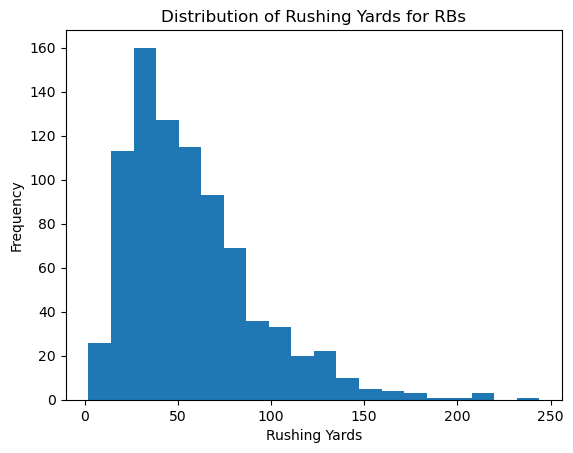

In [ ]:
# Rushing yards distribution for RBs only with at least 5 rush attempts
rb_df = df[df['player_position'] == 'RB']
rb_df = rb_df[rb_df['stats_rushing_rush_attempts'] > 5]
plt.hist(rb_df['stats_rushing_rush_yards'], bins=20)
plt.title('Distribution of Rushing Yards for RBs')
plt.xlabel('Rushing Yards')
plt.ylabel('Frequency')
plt.show()

# Skewed right

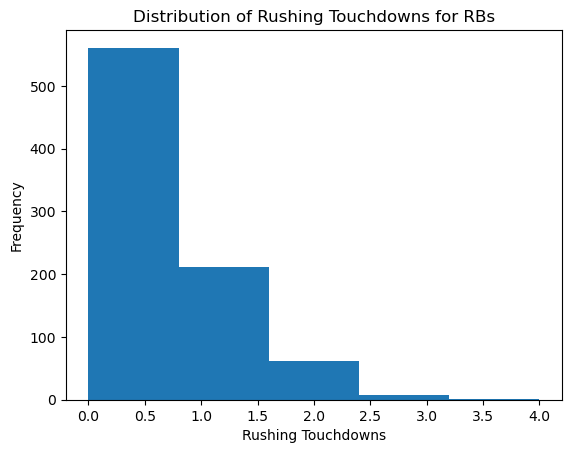

In [ ]:
# Rushing TDs
plt.hist(rb_df['stats_rushing_rush_td'], bins=5)
plt.title('Distribution of Rushing Touchdowns for RBs')
plt.xlabel('Rushing Touchdowns')
plt.ylabel('Frequency')
plt.show()

# skewed right, zero-inflated

## Receiving statistics

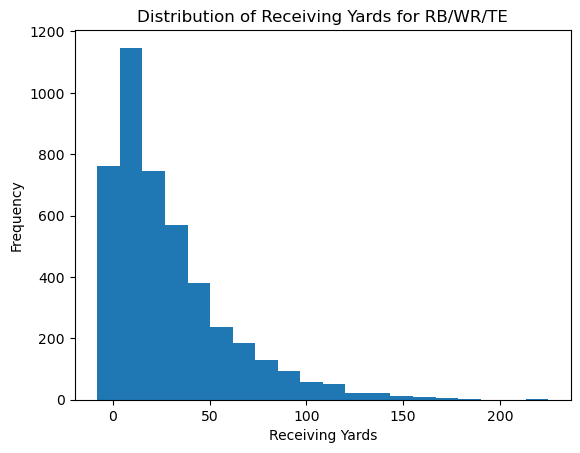

In [ ]:
# Receiving yards distribution for RB/WR/TE with at least 1 target
rec_df = df[df['player_position'].isin(['RB', 'WR', 'TE'])]
rec_df = rec_df[rec_df['stats_receiving_targets'] > 0]
plt.hist(rec_df['stats_receiving_rec_yards'], bins=20)
plt.title('Distribution of Receiving Yards for RB/WR/TE')
plt.xlabel('Receiving Yards')
plt.ylabel('Frequency')
plt.show()

# skewed right

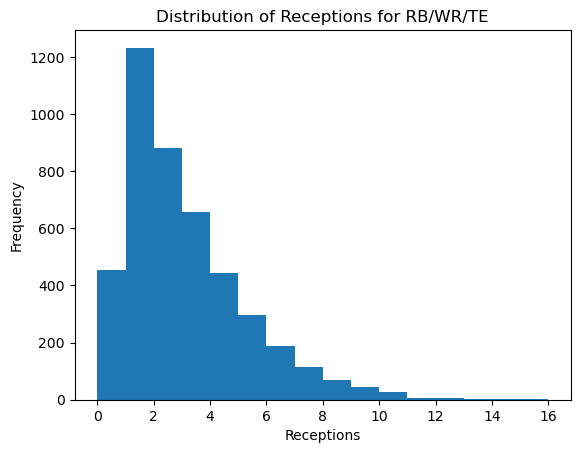

In [ ]:
# Receptions
plt.hist(rec_df['stats_receiving_receptions'], bins=16)
plt.title('Distribution of Receptions for RB/WR/TE')
plt.xlabel('Receptions')
plt.ylabel('Frequency')
plt.show()

# Skewed right

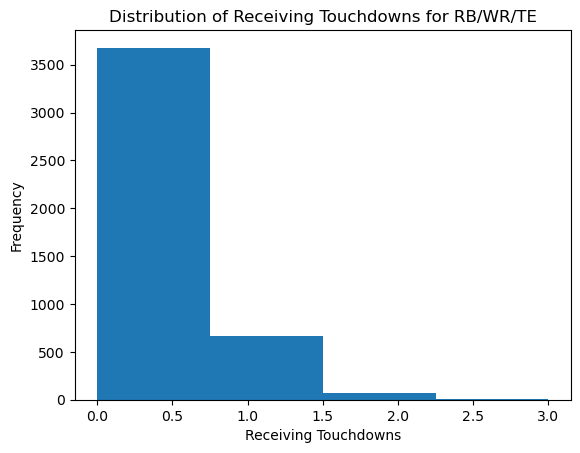

In [ ]:
# Receiving TDs
plt.hist(rec_df['stats_receiving_rec_td'], bins=4)
plt.title('Distribution of Receiving Touchdowns for RB/WR/TE')
plt.xlabel('Receiving Touchdowns')
plt.ylabel('Frequency')
plt.show()

# Very skewed, zero-inflated

## Defensive statistics

In [38]:
print(df['player_position'].value_counts())

player_position
LB     3861
WR     2898
CB     2701
FS     2002
DT     1926
DE     1859
TE     1777
RB     1732
G      1455
T      1343
C       880
QB      700
K       567
LS      566
P       564
OT      483
DB      366
OLB     260
FB      187
NT      119
ILB      94
MLB      70
SS        8
Name: count, dtype: int64


In [39]:
# Create df
def_df = df[df['player_position'].isin(['LB', 'CB', 'FS', 'DT', 'DE', 'DB', 'OLB', 'ILB', 'MLB', 'SS'])]

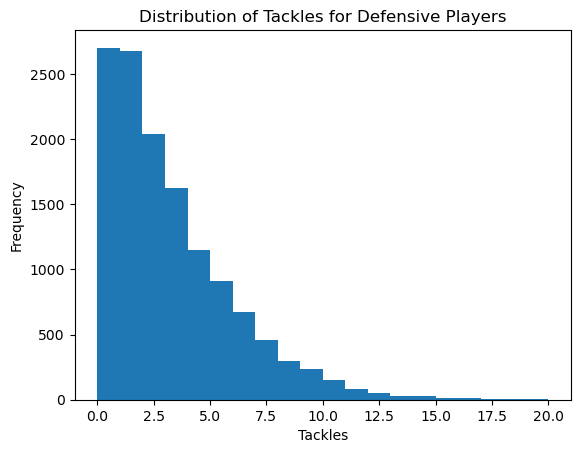

In [ ]:
# Tackles distribution for defensive players
plt.hist(def_df['stats_tackles_tackle_total'], bins=20)
plt.title('Distribution of Tackles for Defensive Players')
plt.xlabel('Tackles')
plt.ylabel('Frequency')
plt.show()

# zero-inflated, skewed right

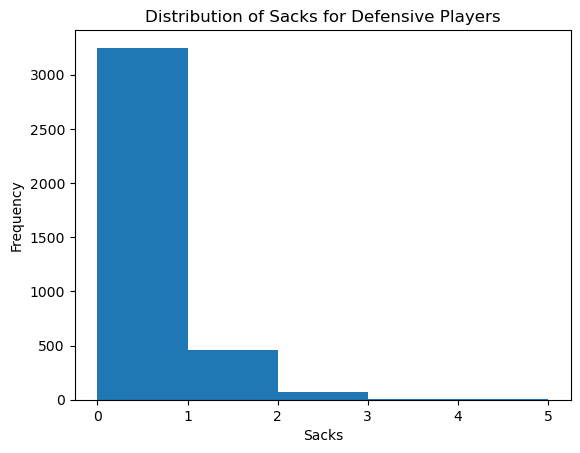

In [46]:
# sack distribution for defensive ends and defensive tackles
plt.hist(def_df[def_df['player_position'].isin(['DE', 'DT'])]['stats_tackles_sacks'], bins=5)
plt.title('Distribution of Sacks for Defensive Players')
plt.xlabel('Sacks')
plt.ylabel('Frequency')
plt.show()

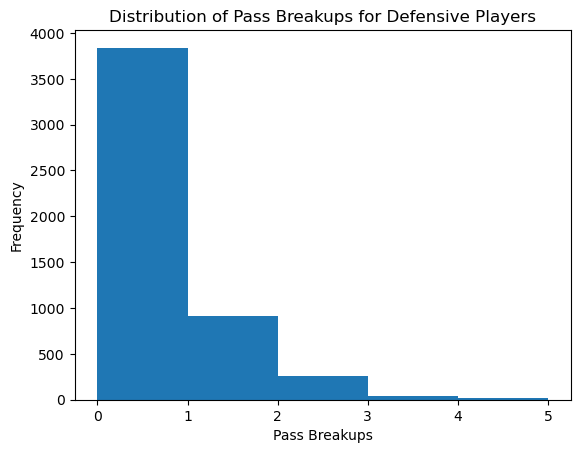

In [51]:
# Pass breakups distribution for defensive backs
plt.hist(def_df[def_df['player_position'].isin(['CB', 'FS', 'SS', 'DB'])]['stats_interceptions_passes_defended'], bins=5)
plt.title('Distribution of Pass Breakups for Defensive Players')
plt.xlabel('Pass Breakups')
plt.ylabel('Frequency')
plt.show()

# 2D EDA

We'll look at if statistics within the same category are correlated. If so, we may be able to pick one to use in our correlation analysis

## Passing statistics

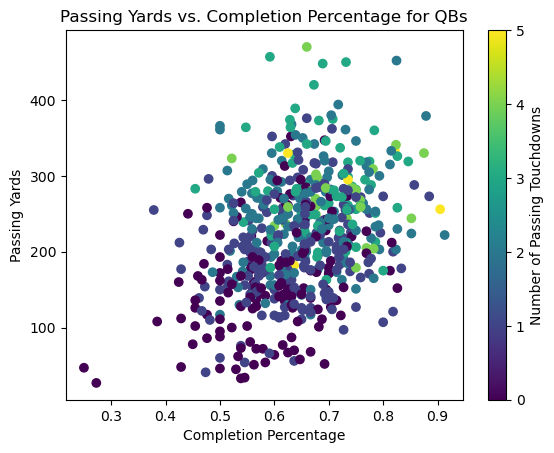

In [29]:
# Passing yards against completion percentage for QBs, colored by number of TDs
plt.scatter(comp_pcts, qb_df['stats_passing_pass_yards'], c=qb_df['stats_passing_pass_td'], cmap='viridis')
plt.title('Passing Yards vs. Completion Percentage for QBs')
plt.xlabel('Completion Percentage')
plt.ylabel('Passing Yards')
plt.colorbar(label='Number of Passing Touchdowns')
plt.show()

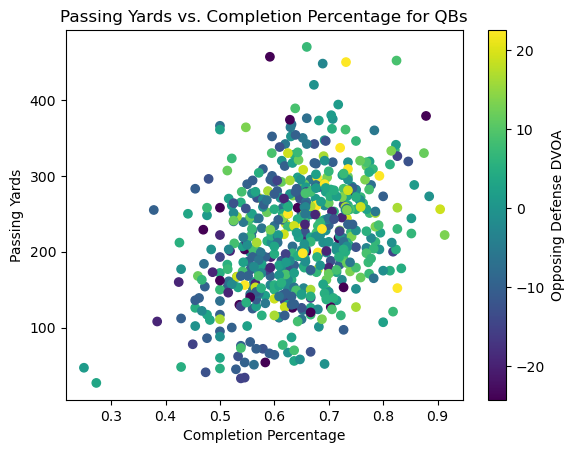

In [ ]:
# Passing yards against completion percentage for QBs, colored by defense DVOA
plt.scatter(comp_pcts, qb_df['stats_passing_pass_yards'], c=qb_df['opp_defense_dvoa'], cmap='viridis')
plt.title('Passing Yards vs. Completion Percentage for QBs')
plt.xlabel('Completion Percentage')
plt.ylabel('Passing Yards')
plt.colorbar(label='Opposing Defense DVOA')
plt.show()

# Not a super apparent correlation with DVOA

## Rushing statistics

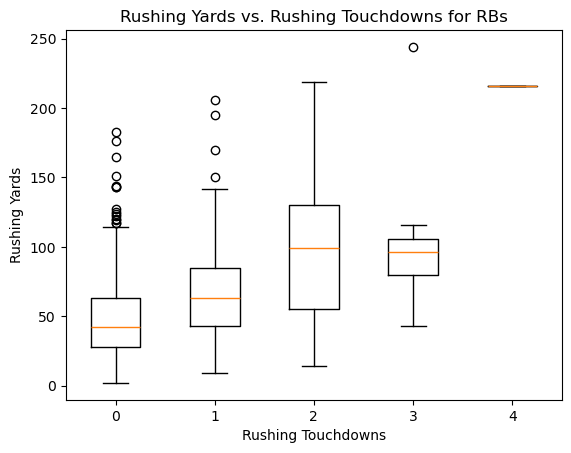

In [ ]:
# Rushing yards vs rushing TDs
plt.boxplot([rb_df[rb_df['stats_rushing_rush_td'] == i]['stats_rushing_rush_yards'] for i in sorted(rb_df['stats_rushing_rush_td'].unique())], tick_labels=sorted(rb_df['stats_rushing_rush_td'].unique()))
plt.title('Rushing Yards vs. Rushing Touchdowns for RBs')
plt.xlabel('Rushing Touchdowns')
plt.ylabel('Rushing Yards')
plt.show()

# Loose positive correlation, but very noisy
# 3+ TDs look like different distribution

## Receiving statistics

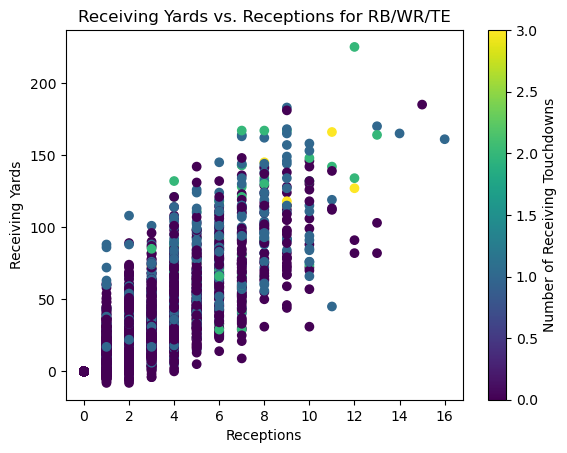

In [ ]:
# receptions vs receiving yards, colored by receiving TDs
plt.scatter(rec_df['stats_receiving_receptions'], rec_df['stats_receiving_rec_yards'], c=rec_df['stats_receiving_rec_td'], cmap='viridis')
plt.title('Receiving Yards vs. Receptions for RB/WR/TE')
plt.xlabel('Receptions')
plt.ylabel('Receiving Yards')
plt.colorbar(label='Number of Receiving Touchdowns')
plt.show()

# moderate positive correlation, but also very noisy

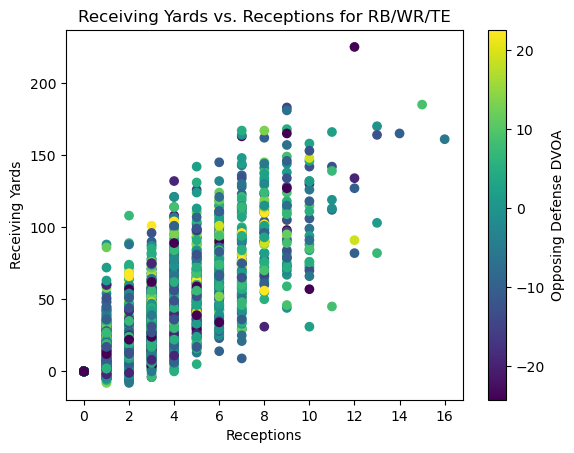

In [ ]:
# receptions vs receiving yards, colored by defense DVOA
plt.scatter(rec_df['stats_receiving_receptions'], rec_df['stats_receiving_rec_yards'], c=rec_df['opp_defense_dvoa'], cmap='viridis')
plt.title('Receiving Yards vs. Receptions for RB/WR/TE')
plt.xlabel('Receptions')
plt.ylabel('Receiving Yards')
plt.colorbar(label='Opposing Defense DVOA')
plt.show()

# No apparent correlation with DVOA

## Total contributions for RBs

In [35]:
# Create new df
rb_tot_df = rb_df.copy()
rb_tot_df['total_yards'] = rb_tot_df['stats_rushing_rush_yards'] + rb_tot_df['stats_receiving_rec_yards']
rb_tot_df['total_tds'] = rb_tot_df['stats_rushing_rush_td'] + rb_tot_df['stats_receiving_rec_td']
rb_tot_df['touches'] = rb_tot_df['stats_rushing_rush_attempts'] + rb_tot_df['stats_receiving_receptions']

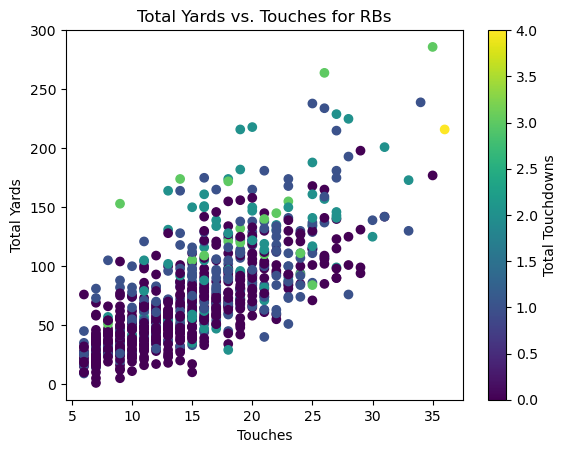

In [ ]:
# total yards vs touches, colored by total TDs
plt.scatter(rb_tot_df['touches'], rb_tot_df['total_yards'], c=rb_tot_df['total_tds'], cmap='viridis')
plt.title('Total Yards vs. Touches for RBs')
plt.xlabel('Touches')
plt.ylabel('Total Yards')
plt.colorbar(label='Total Touchdowns')
plt.show()

# Again, looks about as expected

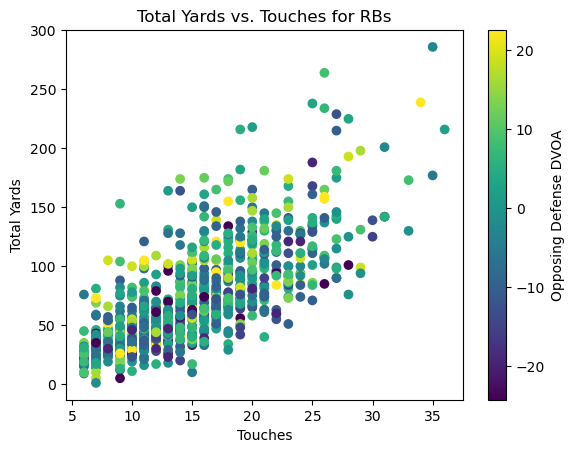

In [ ]:
# total yards vs touches, colored by opposing DVOA
plt.scatter(rb_tot_df['touches'], rb_tot_df['total_yards'], c=rb_tot_df['opp_defense_dvoa'], cmap='viridis')
plt.title('Total Yards vs. Touches for RBs')
plt.xlabel('Touches')
plt.ylabel('Total Yards')
plt.colorbar(label='Opposing Defense DVOA')
plt.show()

# A bit more clear that high DVOA --> fewer yards per touch